<img src="https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main/mse_logo.png" width="400" align="right"/>
<div style="text-align: left"> <b> Machine Learning FTP_MachLe </b> <br> HS 2026 <br> <a href="mailto:christoph.wuersch@ost.ch"> Christoph Würsch </a> </div>

In [37]:
%pip install requests
%pip install pandas
%pip install seaborn
%pip install scikit-learn

# imports
from IPython.display import Image, display
from IPython.display import HTML, Markdown
import os
import requests
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# allow plots to appear directly in the notebook
%matplotlib inline

# raw URL of this repository on GitHub (images, data)
filepath = "https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main"

# **Feature Engineering – Group 2: Feature Transformation**

**Authors:** *Nora Beringer, Malte Gerboth, Haben Ghebremeskel Tekle, Janic Rüegg, Daniel Chung, Raphael Lüthy*

<img src="https://raw.githubusercontent.com/ChristophWuersch/FeatureEngineering_HS2026/main/images/02_Feature_Transformation.png" width="1200"/>

## Introduction

**What is it about?**
*Feature transformation* changes the representation of a feature so that a model can use it more easily. Monotonic transforms such as the logarithm or the square root compress long-tailed distributions and turn multiplicative effects into additive ones. Categorical variables must be turned into numbers, via one-hot encoding for nominal and ordinal encoding for ordered categories. Polynomial features let linear models capture non-linear relationships, and periodic features such as time of day, weekday or angle are best encoded with sine/cosine pairs or radial basis functions so that "23:59" and "00:01" end up close together.

**Where is it used?**
Everywhere tabular data is modelled: prices and incomes (log transform), customer or product categories (one-hot encoding), physical models with interactions (polynomial features), and time series with daily, weekly or seasonal cycles such as energy demand, traffic or sales forecasting (cyclic encoding).

**Why is it important for Machine Learning?**
Most learners make implicit assumptions about their inputs: linear models assume linear effects, distance-based models assume meaningful distances, and no model can directly digest strings. A well-chosen transformation can turn a hard problem into an easy one, often with a simpler model. A poorly chosen one (e.g. label-encoding nominal categories or blindly one-hot encoding high-cardinality features) introduces false orderings, sparsity and the curse of dimensionality.

## (i) Why and when feature transformations make sense



**Why?**  
Feature transformations make sense when the original features do not fit the assumptions or requirements of the machine learning model.

**What do they do?**  
They reshape features to make their **distribution, scale, or relationships** more suitable for modeling.

**When?**
- **Different scales** → standardization / normalization (covered in *Feature Normalization*)
- **Skewed data or outliers** → log or other monotonic transforms reduce the influence of extreme values (section ii)
- **Categorical data** → encode categories numerically (sections iii and iv)
- **Nonlinear relationships** → add polynomial terms (section v)
- **Cyclic data** (hour, weekday, angle) → sine/cosine or radial basis functions (section vi)

**Key idea:**  
> **Transform the features when their current representation makes it harder for the model to learn effectively.**

The rest of this notebook follows this list from top to bottom, starting with the most common problem in practice: skewed numerical features.

## (ii) Log, square root, and monotonic transforms

**Summary:** Use the log for strongly right-skewed, positive data such as income or prices, and the square root for moderately skewed data such as counts, where the log would go too far. Both are monotonic transforms, so they help linear and distance-based models, but make no difference for tree-based models.

### 1. Log transform

**Reason:** In long-tailed features a few extreme values dominate the model. The log compresses them and turns multiplicative effects into additive ones.

**Usage:** Strictly positive, strongly right-skewed data such as income, prices or web traffic. With zeros use log(1 + x) (`np.log1p`).

**In a nutshell:** x' = log(x). Equal ratios become equal distances, so the step from 10 to 100 is as large as from 100 to 1000.

**Python:** `np.log(x)`, or `np.log1p(x)` if the data contains zeros.

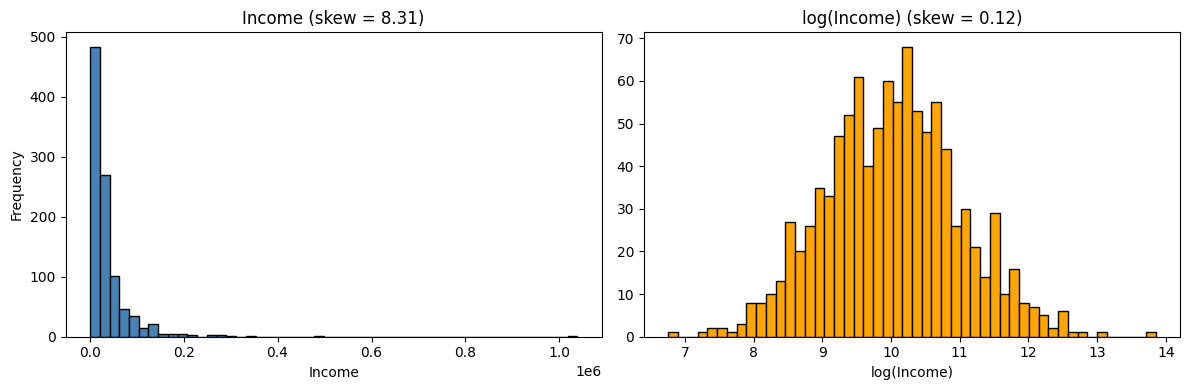

In [4]:
# Simulate right skewed income: few very high values, many low ones
np.random.seed(42)
income = np.random.lognormal(mean=10, sigma=1, size=1000)

# Log transform compresses the long tail
log_income = np.log(income)

# Histograms before and after, skewness in the title (0 = symmetric)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(income, bins=50, edgecolor='black', color='steelblue')
axes[0].set_title(f'Income (skew = {pd.Series(income).skew():.2f})')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Frequency')
axes[1].hist(log_income, bins=50, edgecolor='black', color='orange')
axes[1].set_title(f'log(Income) (skew = {pd.Series(log_income).skew():.2f})')
axes[1].set_xlabel('log(Income)')
plt.tight_layout()
plt.show()

### 2. Square root transform

**Reason:** Milder than the log. Fits moderately skewed data where the log would overcorrect.

**Usage:** Non-negative, moderately right-skewed data such as counts or waiting times. Zeros are allowed.

**In a nutshell:** x' = √x. Pulls in large values, but less strongly than the log.

**Python:** `np.sqrt(x)`.

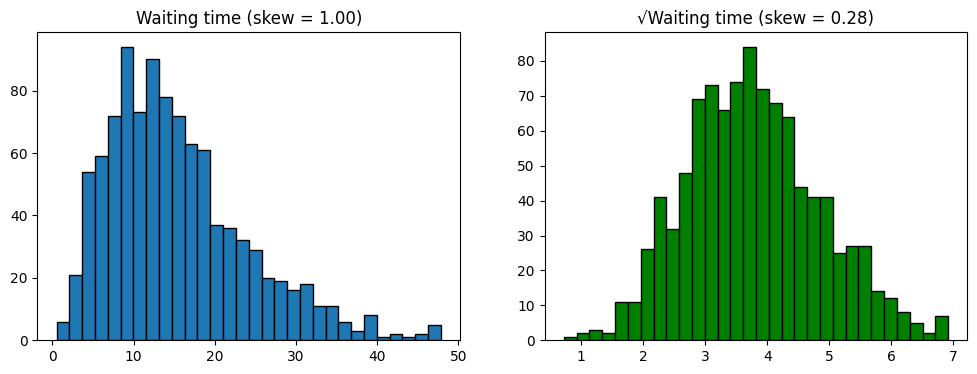

In [9]:
# Moderately right skewed data, e.g. waiting time in minutes
np.random.seed(42)
wait = np.random.gamma(shape=3, scale=5, size=1000)

# Square root transform pulls in the long right tail
sqrt_wait = np.sqrt(wait)

# Before and after, skewness in the title (0 = symmetric)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(wait, bins=30, edgecolor='black')
axes[0].set_title(f'Waiting time (skew = {pd.Series(wait).skew():.2f})')
axes[1].hist(sqrt_wait, bins=30, edgecolor='black', color='green')
axes[1].set_title(f'√Waiting time (skew = {pd.Series(sqrt_wait).skew():.2f})')
plt.show()

### 3. Other monotonic transforms

**Reason:** Log and square root only work for non-negative values (the log even needs x > 0), and you have to pick them by hand. Other monotonic transforms also handle negative values or choose the best transform automatically.

**Usage:**
1. `np.cbrt(x)` (cube root): skewed data with negative values.
2. `np.arcsinh(x)`: behaves like log, but works with 0 and negative values.
3. `PowerTransformer()`: finds the best power automatically (Yeo-Johnson or Box-Cox).
4. `QuantileTransformer()`: replaces each value by its rank and maps it to a normal or uniform distribution. Robust to outliers.

They help linear models and kNN. Trees don't need them, because the order of the values stays the same.

**In a nutshell:** A monotonic function never decreases (or never increases). The order of the values is kept, only the distances between them change.

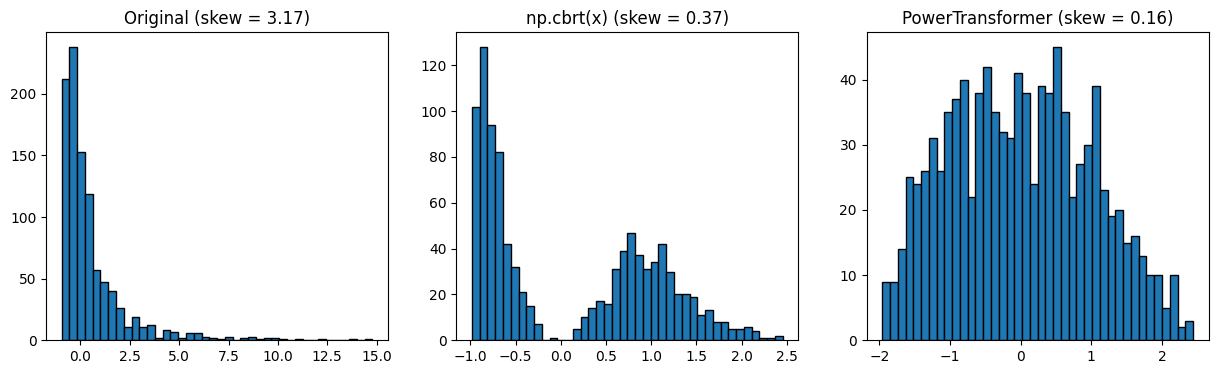

In [6]:
from sklearn.preprocessing import PowerTransformer

# Right skewed data with negative values (log would fail here)
np.random.seed(0)
x = np.random.lognormal(size=1000) - 1

# Cube root by hand vs PowerTransformer, which picks the best power itself (needs a 2D column)
data = {'Original': x,
        'np.cbrt(x)': np.cbrt(x),
        'PowerTransformer': PowerTransformer().fit_transform(x.reshape(-1, 1)).ravel()}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, values) in zip(axes, data.items()):
    ax.hist(values, bins=40, edgecolor='black')
    ax.set_title(f'{name} (skew = {pd.Series(values).skew():.2f})')
plt.show()

## (iii) Categorical features: nominal → one-hot encoding, ordinal → ordinal encoding
The transforms in (ii) reshape features that are already numbers. Categorical features such as "red" or "medium" are not numbers at all, and models compute with numbers, so they must be encoded first. How we encode them depends on whether the categories have an order:

- **Nominal** features have no natural order (colour, country, payment method) → **one-hot encoding**
- **Ordinal** features have a clear order (clothing size: S < M < L) → **ordinal encoding**

### One-hot encoding
Create one 0/1 column per category. "red", "green" and "blue" become three indicator columns, and each row has exactly one 1, so no colour is ranked above another. The cost is one extra column per category: a high-cardinality feature such as postcodes quickly makes the data wide and sparse (see section (iv)).

### Ordinal encoding
Map the categories to integers in their real order, keeping a single column: S → 0, M → 1, L → 2. Two caveats:
- The model treats the codes as equally spaced: *S → M* counts as the same step as *M → L*, even if the real gap is different.
- In scikit-learn, use `OrdinalEncoder` with explicit `categories=`. `LabelEncoder` is meant for target labels, not input features.

**Rule of thumb:** if you can't say which category is "more", the feature is nominal, so use one-hot encoding.

### Example
Let's look at a small dataset of 24 Swiss hiking trips: where people went, how they got there, which snack they packed, and how hard, hungry and happy the trip was.

In [38]:
import pandas as pd

swiss_trips = pd.read_csv("data/swiss_hiking_snacks.csv")

nominal_features = ["canton", "transport", "snack"]
ordinal_orders = {
    "trail_difficulty": ["Easy", "Moderate", "Challenging"],
    "hunger": ["Not hungry", "Peckish", "Hungry", "Very hungry"],
    "satisfaction": ["Unhappy", "Neutral", "Happy", "Delighted"],
}

swiss_trips.head(3)

,trip_id,canton,transport,snack,trail_difficulty,hunger,satisfaction
0,CH001,Valais,Train,Raclette,Moderate,Very hungry,Delighted
1,CH002,Bern,PostBus,Chocolate,Easy,Peckish,Happy
2,CH003,Graubuenden,Cable car,Nusstorte,Challenging,Hungry,Neutral


Each trip has three **nominal** features (`canton`, `transport`, `snack`): there is no natural order between Valais and Ticino, or between a train and a cable car. It also has three **ordinal** features (`trail_difficulty`, `hunger`, `satisfaction`), whose categories have a clear order. So we encode the two groups differently.

#### Step 1: One-hot encode the nominal features
We start with `snack`. `OneHotEncoder` creates one 0/1 column for each snack. In every row, exactly one of these columns is `1`: the one for that trip's snack. With `handle_unknown="ignore"`, a snack the encoder has never seen (e.g. in new data at prediction time) does not raise an error; it simply gets `0` in all snack columns.

In [39]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

onehot = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
snack_onehot = pd.DataFrame(
    onehot.fit_transform(swiss_trips[["snack"]]).astype(int),
    columns=onehot.get_feature_names_out(),
    index=swiss_trips.index,
)

pd.concat([swiss_trips[["snack"]], snack_onehot], axis=1).head(6)

,snack,snack_Appenzeller cheese,snack_Chocolate,snack_Nusstorte,snack_Polenta,snack_Raclette
0,Raclette,0,0,0,0,1
1,Chocolate,0,1,0,0,0
2,Nusstorte,0,0,1,0,0
3,Appenzeller cheese,1,0,0,0,0
4,Polenta,0,0,0,1,0
5,Raclette,0,0,0,0,1


#### Step 2: Ordinal encode the ordinal features
For ordinal features we pass the order **explicitly** via `categories=`. Each feature stays a single column, and a larger number means "more difficult", "hungrier" or "happier".

In [40]:
ordinal_features = list(ordinal_orders)

display(Markdown(
    "**Ordinal features and their order:**\n\n"
    + "\n".join(f"- `{feature}`: " + " < ".join(order) for feature, order in ordinal_orders.items())
))

ordinal = OrdinalEncoder(categories=list(ordinal_orders.values()))
ordinal_encoded = pd.DataFrame(
    ordinal.fit_transform(swiss_trips[ordinal_features]).astype(int),
    columns=[f"{feature}_encoded" for feature in ordinal_features],
    index=swiss_trips.index,
)

pd.concat([swiss_trips[ordinal_features], ordinal_encoded], axis=1).head(6)

**Ordinal features and their order:**

- `trail_difficulty`: Easy < Moderate < Challenging
- `hunger`: Not hungry < Peckish < Hungry < Very hungry
- `satisfaction`: Unhappy < Neutral < Happy < Delighted

,trail_difficulty,hunger,satisfaction,trail_difficulty_encoded,hunger_encoded,satisfaction_encoded
0,Moderate,Very hungry,Delighted,1,3,3
1,Easy,Peckish,Happy,0,1,2
2,Challenging,Hungry,Neutral,2,2,1
3,Easy,Not hungry,Happy,0,0,2
4,Moderate,Hungry,Delighted,1,2,3
5,Challenging,Very hungry,Unhappy,2,3,0


#### What goes wrong if we mix them up?
Without explicit categories, `OrdinalEncoder` simply sorts the categories **alphabetically**. This causes two problems:

- **Nominal feature as integers:** the snacks get the numbers 0–4. A linear model now believes that Raclette (4) is "four times more snack" than Chocolate (1), and that the average of Appenzeller cheese (0) and Raclette (4) is a Nusstorte (2). 🧀 + 🫕 = 🥧?
- **Ordinal feature without explicit order:** alphabetically, *Challenging* < *Easy* < *Moderate*, so the trail order is scrambled.

In [41]:
lines = []
for feature in ["snack", "trail_difficulty"]:
    naive = OrdinalEncoder().fit(swiss_trips[[feature]])
    mapping = ", ".join(f"{category} → {code}" for code, category in enumerate(naive.categories_[0])) # type: ignore
    lines.append(f"- `{feature}`: {mapping}")
display(Markdown("**Naive integer encoding (alphabetical):**\n\n" + "\n".join(lines)))

**Naive integer encoding (alphabetical):**

- `snack`: Appenzeller cheese → 0, Chocolate → 1, Nusstorte → 2, Polenta → 3, Raclette → 4
- `trail_difficulty`: Challenging → 0, Easy → 1, Moderate → 2

#### Seeing it: which distances does the model "see"?
Many models (k-NN, SVMs, clustering, linear models with regularisation) work with **distances** between samples. The encoding decides these distances. Each panel below picks one category and shows how far every other category is from it after encoding:

- **Top left:** with integer encoding, the snacks form a staircase. Appenzeller cheese is 4 away from Raclette, but Polenta is only 1 away. That ranking comes from the alphabet, not from the snacks.
- **Top right:** with one-hot encoding, all bars are equal: every other snack is $\sqrt{2} \approx 1.41$ away. No snack is "closer" than another, which is exactly what *nominal* means.
- **Bottom left:** for `trail_difficulty` the integer distances *are* meaningful. Easy → Moderate is one step, Easy → Challenging is two.
- **Bottom right:** one-hot encoding flattens this order and uses more columns.

**Rule of thumb:** pick the encoding whose distances match how you think about the categories: a staircase for ordered categories, flat bars for unordered ones.

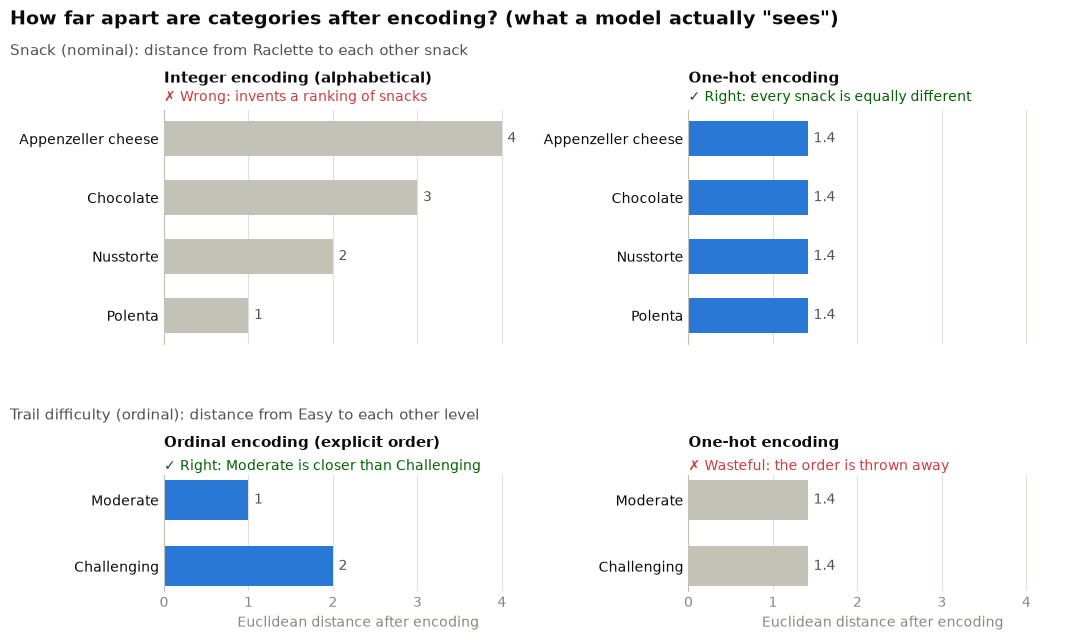

In [42]:
from sklearn.metrics import pairwise_distances


def distances_from(reference, categories, encoder):
    """Euclidean distance from `reference` to every other category after encoding."""
    encoded = encoder.fit_transform(pd.DataFrame({"x": categories}))
    dist = pd.Series(pairwise_distances(encoded)[categories.index(reference)], index=categories)
    return dist.drop(reference)


snacks = sorted(swiss_trips["snack"].unique())
difficulties = ordinal_orders["trail_difficulty"]

rows = [
    ("Snack (nominal): distance from Raclette to each other snack", [
        ("Integer encoding (alphabetical)", False, "Wrong: invents a ranking of snacks",
         distances_from("Raclette", snacks, OrdinalEncoder())),
        ("One-hot encoding", True, "Right: every snack is equally different",
         distances_from("Raclette", snacks, OneHotEncoder(sparse_output=False))),
    ]),
    ("Trail difficulty (ordinal): distance from Easy to each other level", [
        ("Ordinal encoding (explicit order)", True, "Right: Moderate is closer than Challenging",
         distances_from("Easy", difficulties, OrdinalEncoder(categories=[difficulties]))),
        ("One-hot encoding", False, "Wasteful: the order is thrown away",
         distances_from("Easy", difficulties, OneHotEncoder(sparse_output=False, categories=[difficulties]))),
    ]),
]

# colors: blue bars = good encoding, gray bars = bad encoding; verdict text in status color + icon
INK, INK_2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BAR_GOOD, BAR_BAD = "#2a78d6", "#c3c2b7"
TEXT_GOOD, TEXT_BAD = "#006300", "#d03b3b"

xmax = max(dist.max() for _, panels in rows for *_, dist in panels) * 1.15
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [4, 2]})
fig.subplots_adjust(left=0.15, right=0.98, top=0.83, bottom=0.09, wspace=0.35, hspace=0.75)
fig.suptitle('How far apart are categories after encoding? (what a model actually "sees")',
             fontsize=14, fontweight="bold", x=0.01, y=0.985, ha="left", color=INK)

for row_axes, (row_title, panels) in zip(axes, rows):
    fig.text(0.01, row_axes[0].get_position().y1 + 0.085, row_title, fontsize=11, color=INK_2)
    for ax, (encoding, is_good, verdict, dist) in zip(row_axes, panels):
        ax.barh(dist.index, dist.values, height=0.6, color=BAR_GOOD if is_good else BAR_BAD)
        ax.bar_label(ax.containers[0], fmt="%.2g", padding=4, color=INK_2)
        ax.invert_yaxis()
        ax.set_xlim(0, xmax)
        ax.set_title(encoding, fontsize=11, fontweight="bold", loc="left", color=INK, pad=20)
        ax.text(0, 1.04, f"{'✓' if is_good else '✗'} {verdict}", transform=ax.transAxes,
                fontsize=10, color=TEXT_GOOD if is_good else TEXT_BAD)
        ax.tick_params(axis="both", length=0, labelsize=10)
        ax.tick_params(axis="x", labelcolor=MUTED)
        ax.tick_params(axis="y", labelcolor=INK)
        ax.spines[["top", "right", "bottom"]].set_visible(False)
        ax.spines["left"].set_color("#c3c2b7")
        ax.grid(axis="x", color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
for ax in axes[1]:
    ax.set_xlabel("Euclidean distance after encoding", color=MUTED, fontsize=10)

plt.show()

One-hot encoding all three nominal features (6 cantons, 4 transport modes, 5 snacks) turns `3` columns into `15`, and in every row `12` of these `15` entries are 0. With only a handful of categories this is harmless. But what happens with hundreds of categories? That is the topic of the next section.

## (iv) Problems with one-hot encoding (sparsity, curse of dimensionality)

Section (iii) showed that one-hot encoding is the right choice for nominal features because it does not invent an order. It runs into trouble, however, with **high-cardinality features**: categorical features with many unique values, such as postcodes, product IDs or usernames.

### Core issues

1. **Sparsity**
   - A feature with $K$ categories becomes $K$ binary columns.
   - In every row, exactly **one column is `1` and the other $K-1$ are `0`**.
   - As $K$ grows, the matrix is almost entirely zeros. Stored densely, this wastes memory and computation time, which is why `OneHotEncoder` returns a sparse matrix by default.

2. **Curse of dimensionality**
   - Every category adds a dimension, so hundreds of categories mean hundreds of new columns.
   - **Overfitting:** rare categories are backed by only a few training samples, so the model easily learns noise instead of a real pattern. Categories that never appear in training are all zeros at prediction time.
   - **Computational cost:** training time grows with the number of features.
   - **Less meaningful distances:** as we saw in (iii), one-hot encoding puts every pair of categories at the same distance. Together with many dimensions, distances in $k$-NN or SVMs carry little information.

3. **Multicollinearity (dummy variable trap)**
   - The $K$ one-hot columns always sum to 1, so any one of them can be computed from the others.
   - Without regularization, the coefficients of a linear or logistic regression are then no longer unique. The fix is to drop one column (`drop='first'`) or to use $L_1$/$L_2$ regularization.

---

### Practical alternatives for high-cardinality features

* **Rare category grouping:** merge infrequent categories into a single `"Other"` bucket before encoding (`OneHotEncoder(min_frequency=...)` or `max_categories=...`).
* **Frequency / count encoding:** replace each category with how often it occurs in the dataset.
* **Target / mean encoding:** replace each category with the mean target value for that category. Needs smoothing or cross-fitting to avoid target leakage (`TargetEncoder` in scikit-learn).
* **Feature hashing (hashing trick):** hash the categories into a fixed, smaller number of columns (`FeatureHasher`).
* **Entity embeddings:** let a neural network learn a short, dense vector per category.

The code below makes the first two problems visible: it one-hot encodes a feature with 100 categories and then trains a logistic regression on increasingly many categories.

Original shape: (1000, 1)
Encoded shape:  (1000, 100)
Matrix Sparsity: 99.00% zeros



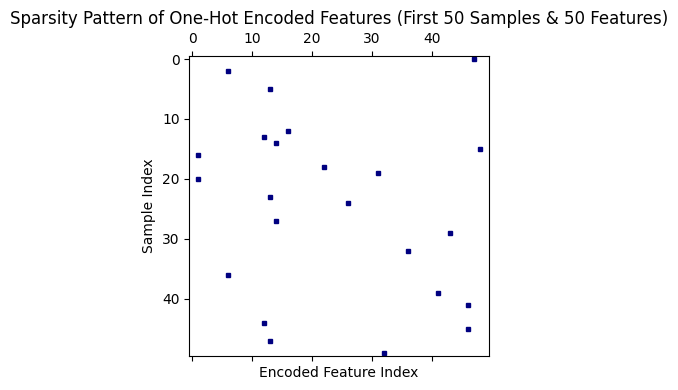

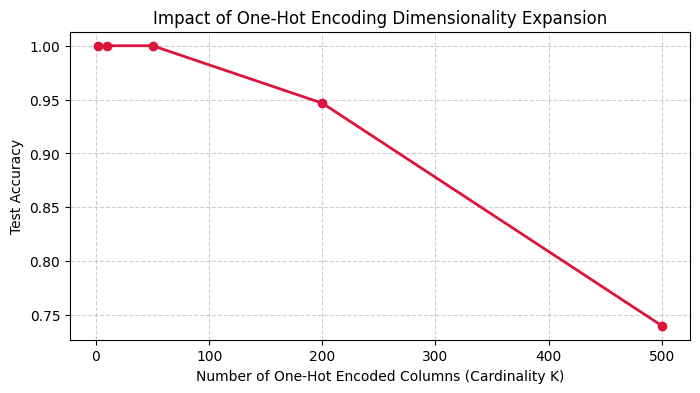

In [2]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ---------------------------------------------------------
# 1. Visualizing Sparsity & Dimensionality Expansion
# ---------------------------------------------------------
# Create a dummy dataset with high-cardinality features
np.random.seed(42)
n_samples = 1000
high_cardinality_feature = np.random.choice([f"Category_{i}" for i in range(100)], size=n_samples)

df_demo = pd.DataFrame({"HighCard_Feature": high_cardinality_feature})

encoder = OneHotEncoder(sparse_output=False)
ohe_matrix = encoder.fit_transform(df_demo[["HighCard_Feature"]])

# Calculate Sparsity
total_elements = ohe_matrix.size
zero_elements = np.sum(ohe_matrix == 0)
sparsity = (zero_elements / total_elements) * 100

print(f"Original shape: {df_demo.shape}")
print(f"Encoded shape:  {ohe_matrix.shape}")
print(f"Matrix Sparsity: {sparsity:.2f}% zeros\n")

# Plot the Sparse Matrix
plt.figure(figsize=(10, 4))
plt.spy(ohe_matrix[:50, :50], markersize=3, color="navy")
plt.title("Sparsity Pattern of One-Hot Encoded Features (First 50 Samples & 50 Features)")
plt.xlabel("Encoded Feature Index")
plt.ylabel("Sample Index")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Impact on Model Performance (Curse of Dimensionality)
# ---------------------------------------------------------
# Simulate model accuracy vs number of encoded noisy categorical features
dimensions = [2, 10, 50, 200, 500]
acc_scores = []

for d in dimensions:
    # Generate random high-cardinality categorical data + binary target
    X_categories = np.random.randint(0, d, size=(500, 1))
    ohe = OneHotEncoder(sparse_output=False)
    X_ohe = ohe.fit_transform(X_categories)

    # Generate target weakly correlated with first few categories
    y = (X_categories.ravel() % 2 == 0).astype(int)

    X_train, X_test, y_train, y_test = train_test_split(X_ohe, y, test_size=0.3, random_state=42)

    model = LogisticRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc_scores.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(8, 4))
plt.plot(dimensions, acc_scores, marker='o', linewidth=2, color='crimson')
plt.title("Impact of One-Hot Encoding Dimensionality Expansion")
plt.xlabel("Number of One-Hot Encoded Columns (Cardinality K)")
plt.ylabel("Test Accuracy")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

**What the plots show:**
- With 100 categories, **99 % of the matrix is zeros**: each row has a single `1` among 100 columns.
- The target is a simple rule (even vs. odd category), so with few categories the model gets it perfectly right. With 200 or 500 categories but only 350 training rows, many categories are seen once or never during training, and **test accuracy drops** (to about 0.74 at 500 categories). The rule did not get harder; the data per column simply got too thin.

One-hot encoding adds one column per *category*. The next section adds new columns in a different way: by combining existing *numerical* features to capture non-linear effects.

## (v) Polynomial features

**Reason:** A linear model can only draw straight lines (or flat planes). Many real relationships are curved, for example braking distance grows with the *square* of speed.

**Idea:** Add powers and products of the existing features as new columns, e.g. $x \to (x, x^2)$ or $(x_1, x_2) \to (x_1, x_2, x_1^2, x_1 x_2, x_2^2)$. The model is still linear in its weights, so it is trained exactly like before, but as a function of the original $x$ it can now draw curves.

**Python:** `PolynomialFeatures(degree=2)` from `sklearn.preprocessing`.

<img src="https://global.discourse-cdn.com/dlai/original/3X/b/8/b8c30f9c214c9d7eaac0338bc9d87610c6fbef80.jpeg" width="1200"/>

*Figure: the same data fitted with polynomial features of increasing degree (source: DeepLearning.AI community forum, see references).*

- **Degree 1:** too simple for a curved relationship → underfitting
- **Degree 2:** may capture a quadratic relationship well
- **Degree 10:** follows the random noise in the training data → overfitting

The degree is therefore a hyperparameter that should be chosen with validation data. In the minimal example below, the target is generated by $y = 2x + x^2$, so degree 2 is exactly right.

In [34]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Original dataset
X = np.array([[1], [2], [3], [4], [5]])
# Example target values
y = np.array([3, 8, 15, 24, 35])

# Apply polynomial transformation
poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)
X_poly_y = np.column_stack((X_poly, y))

print("Polynomial Features with Target:")
print(X_poly_y)

Original Features
[[1]
 [2]
 [3]
 [4]
 [5]]
Polynomial Features with Target:
[[ 1.  1.  3.]
 [ 2.  4.  8.]
 [ 3.  9. 15.]
 [ 4. 16. 24.]
 [ 5. 25. 35.]]


`PolynomialFeatures` turned the single column $x$ into two columns, $x$ and $x^2$ (the last column printed above is the target $y$). A plain `LinearRegression` on these two columns can now recover the curve $y = 2x + x^2$ exactly and predict a value it has never seen:

In [38]:
model = LinearRegression()
model.fit(X_poly, y)

# Predict for x = 6
X_new = poly.transform([[6]])
prediction = model.predict(X_new)

print("Predictions for x=6:")
print(prediction)

Predictions for x=6:
[48.]


The model predicts **48** for $x = 6$, which is exactly $2 \cdot 6 + 6^2$.

**Watch out:** the number of polynomial features grows quickly. With $d$ input features and degree $p$ there are $\binom{d+p}{p} - 1$ output columns, e.g. 10 features at degree 3 already give 285 columns. This brings back the curse of dimensionality from (iv). Scale the features first (powers of large values explode), and use regularization.

Polynomials can bend a line, but they always shoot off to $\pm\infty$ at the edges. They cannot express a pattern that **repeats**, such as a daily cycle where 23:00 is followed by 00:00. That is what periodic features are for.

## (vi) Periodic features: sine/cosine encoding and radial basis functions

Imagine your goal is to predict a household's electricity consumption (in kW) from the hour of day.

- Input (feature): `hour` (0 to 23)
- Output (target): `consumption`
- Model: linear regression, deliberately simple so the effect of the encoding is easy to see

The real pattern is cyclical: consumption is lowest at night (minimum around 6:00) and highest in the evening (maximum around 18:00). At 23:00 and 0:00 it is practically the same, since only one hour separates them.

### Sine/cosine encoding

A linear regression with the raw `hour` as feature learns:

$$\text{consumption} = w \cdot \text{hour} + b$$

This is a straight line: consumption rises or falls monotonically across the whole day. It cannot represent consumption being high in the evening and dropping again after midnight, and it treats 23:00 and 0:00 as the two most different hours. The fit stays poor no matter how much data you have.

With sine/cosine encoding, the model gets two features instead:

$$\text{consumption} = a \cdot \sin\left(\frac{2\pi \cdot \text{hour}}{24}\right) + b \cdot \cos\left(\frac{2\pi \cdot \text{hour}}{24}\right) + c$$

The sum of a sine and a cosine component is always a **shifted cosine wave**:

$$a\sin\theta + b\cos\theta = A\cos(\theta - \varphi)$$

with amplitude $A = \sqrt{a^2 + b^2}$ and phase $\varphi = \text{atan2}(a, b)$. Through $a$ and $b$, the linear model therefore automatically learns:

- **how strongly** the daily rhythm swings (amplitude)
- **at what time** the maximum occurs (phase)

All of this happens although the model is only linear in $a$ and $b$. This is why you need **both** features: with sine alone, the position of the peak would be fixed.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Synthetic data: peak at 18:00, trough at 06:00, plus noise
rng = np.random.default_rng(0)
hour = rng.integers(0, 24, size=1000)
y = 2.0 + 1.0 * np.cos(2*np.pi*(hour - 18)/24) + rng.normal(0, 0.15, size=1000)
df = pd.DataFrame({"hour": hour, "y": y})

# Two feature sets, same model
X_raw = df[["hour"]]
X_cyc = pd.DataFrame({
    "hour_sin": np.sin(2*np.pi*df["hour"]/24),
    "hour_cos": np.cos(2*np.pi*df["hour"]/24),
})

m_raw = LinearRegression().fit(X_raw, df["y"])
m_cyc = LinearRegression().fit(X_cyc, df["y"])

print(f"Raw hour : R² = {r2_score(df['y'], m_raw.predict(X_raw)):.3f}")
print(f"Sin/Cos  : R² = {r2_score(df['y'], m_cyc.predict(X_cyc)):.3f}")

Raw hour : R² = 0.576
Sin/Cos  : R² = 0.960


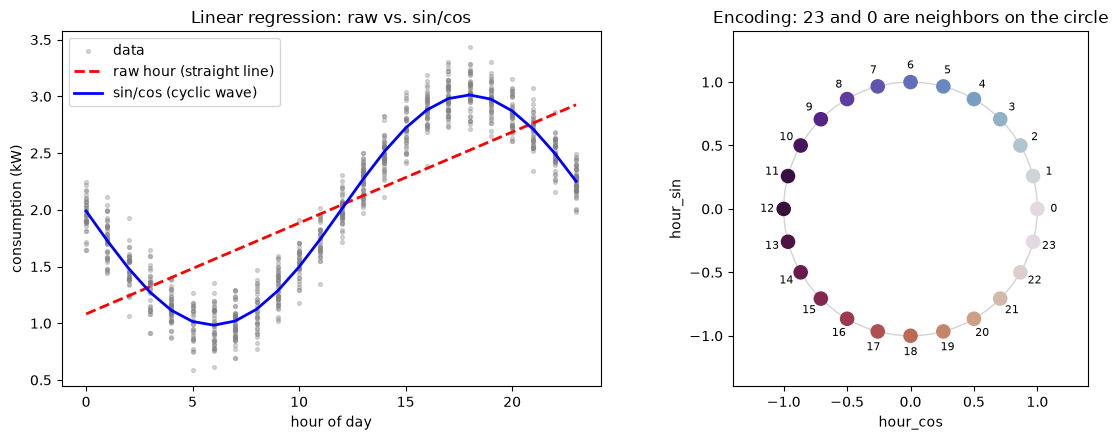

In [10]:
# Visualisation
grid = np.arange(0, 24)
G_raw = pd.DataFrame({"hour": grid})
G_cyc = pd.DataFrame({"hour_sin": np.sin(2*np.pi*grid/24),
                      "hour_cos": np.cos(2*np.pi*grid/24)})

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: fits in original hour space
ax[0].scatter(df["hour"], df["y"], s=8, alpha=0.3, color="gray", label="data")
ax[0].plot(grid, m_raw.predict(G_raw), "r--", lw=2, label="raw hour (straight line)")
ax[0].plot(grid, m_cyc.predict(G_cyc), "b-", lw=2, label="sin/cos (cyclic wave)")
ax[0].set(xlabel="hour of day", ylabel="consumption (kW)", title="Linear regression: raw vs. sin/cos")
ax[0].legend()

# Right: the encoding itself, hours on the unit circle
ax[1].add_patch(plt.Circle((0, 0), 1, fill=False, color="lightgray"))
sc = ax[1].scatter(G_cyc["hour_cos"], G_cyc["hour_sin"], c=grid, cmap="twilight", s=90, zorder=3)
for h in grid:
    ax[1].annotate(str(h), (G_cyc["hour_cos"][h]*1.13, G_cyc["hour_sin"][h]*1.13),
                   ha="center", va="center", fontsize=8)
ax[1].set(xlim=(-1.4, 1.4), ylim=(-1.4, 1.4), aspect="equal",
          xlabel="hour_cos", ylabel="hour_sin",
          title="Encoding: 23 and 0 are neighbors on the circle")
plt.tight_layout()
plt.show()

- **Raw hour:** R² ≈ 0.58. The straight line (left, red) cannot follow the daily pattern.
- **Sin/cos:** R² ≈ 0.96, close to the maximum possible given the noise. The learned $a$ and $b$ correspond to an amplitude of about 1.0 and a peak at about 18:00, exactly the values used to generate the data.

The right plot shows why: the encoding places the hours on a circle, so 23:00 and 0:00 are neighbours. The model not only predicts better, it also **learns the daily rhythm in an interpretable form**.

### Radial basis functions (RBF)

A single sine/cosine pair can only produce one wave with one peak per day. Now imagine a consumption pattern with **two** peaks, one in the morning at 8:00 and one in the evening at 18:00. Instead of one global wave, we place several localized "bumps" (Gaussians) at chosen centers $c_j$ along the 24-hour cycle. Each feature measures how close the hour is to one center:

$$\varphi_j(x) = \exp\left(-\gamma \cdot d(x, c_j)^2\right)$$

The distance $d$ must be **circular**, which is what makes the encoding periodic:

$$d(x, c) = \min\left(|x - c|,\; P - |x - c|\right), \quad P = 24$$

The linear model then learns one weight per bump, so any smooth shape can be built as a weighted sum of bumps. The code compares this with sine/cosine using one and three harmonics (frequencies $k = 1, 2, 3$).

Sin/Cos (k=1)        features= 2  R² = 0.180
Sin/Cos (k=1,2,3)    features= 6  R² = 0.945
RBF (12 centers)     features=12  R² = 0.955


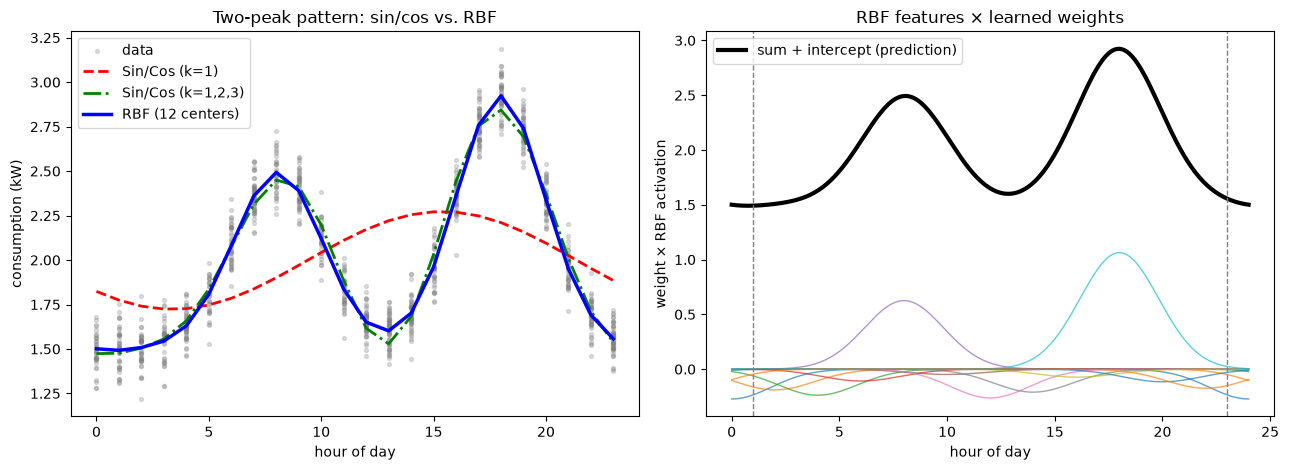

In [12]:
from sklearn.linear_model import Ridge

P = 24

def circ_dist(x, c, period=P):
    d = np.abs(np.asarray(x)[:, None] - np.asarray(c)[None, :])
    return np.minimum(d, period - d)

def gauss(x, mu, sigma):
    return np.exp(-circ_dist(x, [mu]).ravel()**2 / (2 * sigma**2))

# Synthetic data with TWO peaks: 8:00 (smaller) and 18:00 (larger)
rng = np.random.default_rng(0)
hour = rng.integers(0, 24, size=1000)
y = (1.5 + 1.0 * gauss(hour, 8, 2) + 1.4 * gauss(hour, 18, 2)
     + rng.normal(0, 0.1, size=1000))
df = pd.DataFrame({"hour": hour, "y": y})

# Feature Sets
def sincos(h, harmonics=(1,)):
    cols = {}
    for k in harmonics:
        cols[f"sin{k}"] = np.sin(2*np.pi*k*h/P)
        cols[f"cos{k}"] = np.cos(2*np.pi*k*h/P)
    return pd.DataFrame(cols)

centers = np.linspace(0, P, 12, endpoint=False)   # 0, 2, 4, ..., 22
gamma = 0.15

def rbf(h, centers=centers, gamma=gamma):
    h = np.asarray(h)
    return pd.DataFrame(np.exp(-gamma * circ_dist(h, centers)**2),
                        columns=[f"rbf_{int(c)}" for c in centers])

feature_sets = {
    "Sin/Cos (k=1)":       lambda h: sincos(h, (1,)),
    "Sin/Cos (k=1,2,3)":   lambda h: sincos(h, (1, 2, 3)),
    "RBF (12 centers)":    lambda h: rbf(h),
}

models = {}
for name, f in feature_sets.items():
    m = Ridge(alpha=1e-3).fit(f(df["hour"]), df["y"])
    models[name] = m
    print(f"{name:20s} features={f(df['hour']).shape[1]:2d}  "
          f"R² = {r2_score(df['y'], m.predict(f(df['hour']))):.3f}")

# Visualisation
grid = np.arange(0, 24)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

# Left: fits
ax[0].scatter(df["hour"], df["y"], s=8, alpha=0.25, color="gray", label="data")
styles = {"Sin/Cos (k=1)": ("r--", 2), "Sin/Cos (k=1,2,3)": ("g-.", 2), "RBF (12 centers)": ("b-", 2.5)}
for name, f in feature_sets.items():
    s, lw = styles[name]
    ax[0].plot(grid, models[name].predict(f(grid)), s, lw=lw, label=name)
ax[0].set(xlabel="hour of day", ylabel="consumption (kW)",
          title="Two-peak pattern: sin/cos vs. RBF")
ax[0].legend()

# Right: weighted basis functions
fine = np.linspace(0, 24, 400)
Phi = np.exp(-gamma * circ_dist(fine, centers)**2)
m = models["RBF (12 centers)"]
for j, c in enumerate(centers):
    ax[1].plot(fine, Phi[:, j] * m.coef_[j], lw=1, alpha=0.7)
ax[1].plot(fine, Phi @ m.coef_ + m.intercept_, "k-", lw=3, label="sum + intercept (prediction)")
for h in (23, 1):
    ax[1].axvline(h, color="gray", ls="--", lw=1)
ax[1].set(xlabel="hour of day", ylabel="weight × RBF activation",
          title="RBF features × learned weights")
ax[1].legend(loc="upper left")
plt.tight_layout()
plt.show()

- **Sin/cos with one harmonic** (R² ≈ 0.18) fails: one wave cannot have two peaks.
- **Sin/cos with three harmonics** (R² ≈ 0.95) works, because higher frequencies add more wiggles, similar to a Fourier series.
- **RBF with 12 centers** (R² ≈ 0.96) fits best. The right plot shows how the weighted bumps add up to the prediction, and that the curve runs smoothly across midnight (dashed lines at 23:00 and 1:00).

**Rule of thumb:** start with one sine/cosine pair per cycle (hour, weekday, month). Add harmonics or switch to RBFs when the pattern has several peaks. RBFs give local control but need more features and a choice of the number of centers and $\gamma$. scikit-learn's `SplineTransformer(extrapolation="periodic")` is a ready-made alternative.

## Takeaways

- **What should every ML practitioner remember?**
  - ...
- **What are common pitfalls?**
  - ...
- **When does this technique really matter?**
  - ...

## References

*Cite the sources of all figures, diagrams and code snippets (URLs are sufficient).*

1. https://www.geeksforgeeks.org/machine-learning/feature-transformation-techniques-in-machine-learning/ (accessed 8 October 2026)
2. Finney DJ. Was This in Your Statistics Textbook? V. Transformation of Data. Experimental Agriculture. 1989;25(2):165-175. doi:10.1017/S0014479700016665
3. https://www.analyticsvidhya.com/blog/2021/05/feature-transformations-in-data-science-a-detailed-walkthrough/ (accessed 8 October 2026)
4. https://medium.com/@adnan.mazraeh1993/polynomial-features-a-comprehensive-guide-from-basics-to-advanced-5f18c430a137 (accessed 8 October 2026)
5. Wikipedia, «Data transformation (statistics)»: https://en.wikipedia.org/wiki/Data_transformation_(statistics) (accessed 8 October 2026)
6. GeeksforGeeks, «Square Root Transformation»: https://www.geeksforgeeks.org/data-analysis/square-root-transformation/ (accessed 8 October 2026)
7. Scikit-learn Documentation – `OneHotEncoder`: Details on one-hot/dummy encoding implementations, sparse matrix outputs, and handling high-cardinality features. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html (accessed 8 October 2026)
8. Feature-engine Documentation – Categorical Encoding: Overview of high cardinality, data sparsity, rare label encoding, and alternatives to standard One-Hot Encoding. https://feature-engine.trainindata.com/en/1.8.x/user_guide/encoding/index.html (accessed 8 October 2026)
9. Zheng, A., & Casari, A. (2018). *Feature Engineering for Machine Learning: Principles and Techniques for Data Prep*. O'Reilly Media. (Chapter 3: *Building Features: Encoding Categorical Variables*).
10. Figure in section (v), DeepLearning.AI community forum: https://global.discourse-cdn.com/dlai/original/3X/b/8/b8c30f9c214c9d7eaac0338bc9d87610c6fbef80.jpeg
11. Scikit-learn example – Time-related feature engineering (periodic features, splines): https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html
